In [1]:
import os

# Create a folder for Task 5
folder_name = "sales_prediction_data"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Directory '{folder_name}' created successfully!")

Directory 'sales_prediction_data' created successfully!


In [2]:
import urllib.request

# Download standard advertising sales dataset
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/Advertising.csv"
output_path = "sales_prediction_data/Advertising.csv"

try:
    urllib.request.urlretrieve(url, output_path)
    print("Sales dataset downloaded successfully!")
except Exception as e:
    print(f"Download failed: {e}")

Sales dataset downloaded successfully!


In [3]:
import pandas as pd

# Load the data
df = pd.read_csv(output_path)

# Drop the index/unnamed column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(['Unnamed: 0'], axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/131zH3deQka4DOOAgJcGBHWX80X4ABYqvHDUQ8ZPUBxs/edit#gid=0


In [5]:
from sklearn.model_selection import train_test_split

# X contains our advertising budgets, y contains our target sales
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split for training!")

Data successfully split for training!


In [6]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Sales Prediction Model trained successfully!")

Sales Prediction Model trained successfully!


In [7]:
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Make predictions on test data
y_pred = model.predict(X_test)

In [9]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Model Accuracy (R-squared): {r2 * 100:.2f}%")

Mean Squared Error: 3.17
Model Accuracy (R-squared): 89.94%


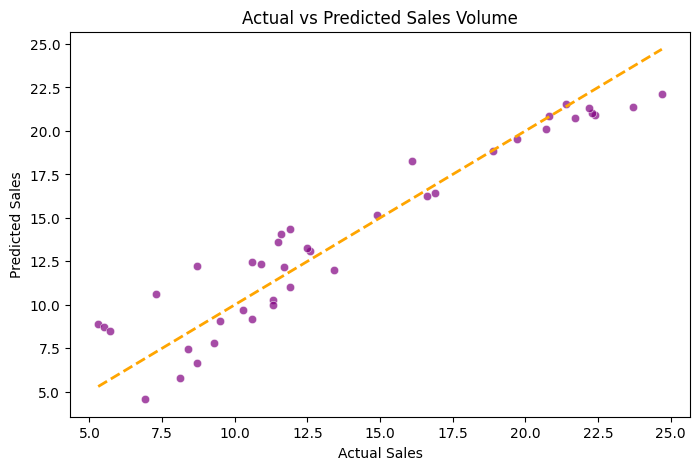

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=2, linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales Volume")
plt.show()